# Exploratory Data Analysis (EDA) - AQI India
This notebook explores the air quality data, showing the steps taken to understand the distributions, correlations, and time-series patterns before building the dashboard and forecasting models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('ggplot')
sns.set_palette('muted')


## 1. Data Loading
In the actual application, data is fetched live from the OpenAQ API. For the purpose of EDA, let's load a sample dataset of historical measurements. If historical data isn't available locally, we will simulate loading and processing the data structures returned by our `fetch_data.py` script.


In [2]:
import os
import sys

# Ensure we can import from our project
sys.path.append(os.path.abspath("."))
from data.fetch_data import fetch_latest_india

print("Fetching latest AQI data from OpenAQ API for EDA...")
df = fetch_latest_india()
display(df.head())


2026-06-17 17:36:48.373 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-17 17:36:48.374 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-17 17:36:48.374 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-17 17:36:48.374 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Fetching latest AQI data from OpenAQ API for EDA...


,city,lat,lon,pm25,pm10,no2,co,so2,o3,last_updated
0,Delhi,28.599998,77.200010,97.1,476.8,13.2,294.0,15.9,147.0,2026-06-17T12:00
1,Mumbai,19.099998,72.900010,11.5,21.1,6.8,176.0,5.1,59.0,2026-06-17T12:00
2,Bengaluru,13.000000,77.600006,20.2,36.7,15.2,711.0,4.4,85.0,2026-06-17T12:00
3,Chennai,13.099998,80.300020,27.1,41.8,6.6,326.0,7.3,138.0,2026-06-17T12:00
4,Kolkata,22.599998,88.399994,35.2,44.4,7.8,445.0,8.3,107.0,2026-06-17T12:00


In [6]:
print(df.columns)

Index(['city', 'lat', 'lon', 'pm25', 'pm10', 'no2', 'co', 'so2', 'o3',
       'last_updated'],
      dtype='str')


## 2. Data Cleaning & Preprocessing
Let's check for missing values and understand the dataset's structure.


In [7]:
# Check data types and missing values
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

# We might have different pollutants in the 'parameter' column. Let's see them:
print("\nAvailable parameters:")
pollutants = ['pm25', 'pm10', 'no2', 'co', 'so2', 'o3']
print("\nAvailable parameters:")
print(pollutants)

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          41 non-null     str    
 1   lat           41 non-null     float64
 2   lon           41 non-null     float64
 3   pm25          41 non-null     float64
 4   pm10          41 non-null     float64
 5   no2           41 non-null     float64
 6   co            41 non-null     float64
 7   so2           41 non-null     float64
 8   o3            41 non-null     float64
 9   last_updated  41 non-null     str    
dtypes: float64(8), str(2)
memory usage: 4.3 KB
None

Missing values per column:
city            0
lat             0
lon             0
pm25            0
pm10            0
no2             0
co              0
so2             0
o3              0
last_updated    0
dtype: int64

Available parameters:

Available parameters:
['pm25', 'pm10', 'no2', 'co', 'so2', 'o3']


To analyze correlations, we should pivot the dataset so that each pollutant has its own column.


In [10]:
df_long = df.melt(
    id_vars=['city', 'lat', 'lon', 'last_updated'],
    value_vars=['pm25', 'pm10', 'no2', 'co', 'so2', 'o3'],
    var_name='parameter',
    value_name='value'
)

display(df_long.head())

,city,lat,lon,last_updated,parameter,value
0,Delhi,28.599998,77.200010,2026-06-17T12:00,pm25,97.1
1,Mumbai,19.099998,72.900010,2026-06-17T12:00,pm25,11.5
2,Bengaluru,13.000000,77.600006,2026-06-17T12:00,pm25,20.2
3,Chennai,13.099998,80.300020,2026-06-17T12:00,pm25,27.1
4,Kolkata,22.599998,88.399994,2026-06-17T12:00,pm25,35.2


## 3. Distributions and Outliers
Let's look at the distribution of PM2.5 and PM10 across the fetched cities. We use boxplots to identify extreme pollution events (outliers).


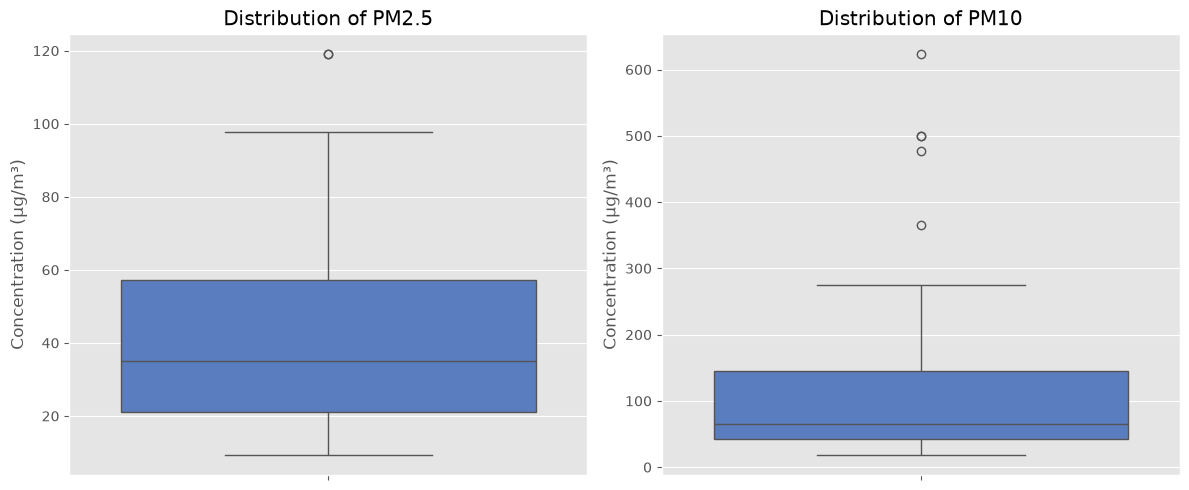

In [14]:
if not df.empty and 'pm25' in df.columns and 'pm10' in df.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df['pm25'])
    plt.title('Distribution of PM2.5')
    plt.ylabel('Concentration (µg/m³)')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df['pm10'])
    plt.title('Distribution of PM10')
    plt.ylabel('Concentration (µg/m³)')
    
    plt.tight_layout()
    plt.show()


## 4. Correlation Matrix
How do different pollutants correlate with each other? For instance, does PM2.5 rise with CO or NO2?


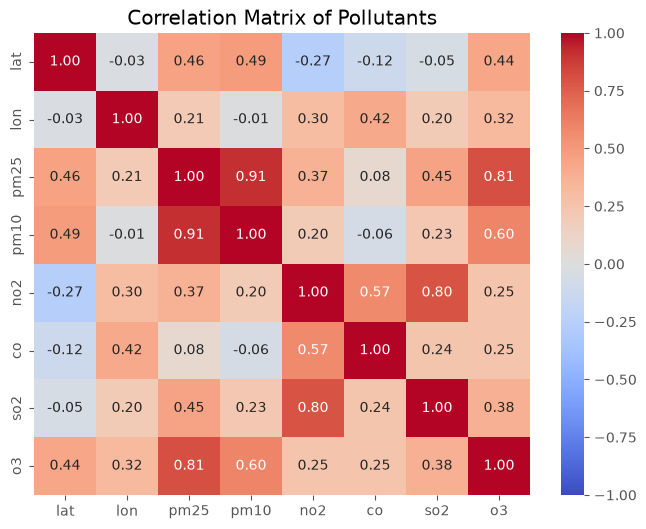

In [15]:
if not df.empty:
    # Select numerical columns (pollutants)
    pollutants = df.select_dtypes(include=[np.number])
    
    if not pollutants.empty and pollutants.shape[1] > 1:
        corr = pollutants.corr()
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
        plt.title('Correlation Matrix of Pollutants')
        plt.show()
    else:
        print("Not enough pollutant data to generate a correlation matrix.")


## 5. Time-Series Analysis Justification
The Prophet model expects a dataframe with `ds` (datetime) and `y` (target variable).
Let's see how a typical time-series would look. (Using simulated historical variation based on current values for demonstration if actual historical endpoints aren't queried here).


Analyzing time-series structure for: Ghaziabad


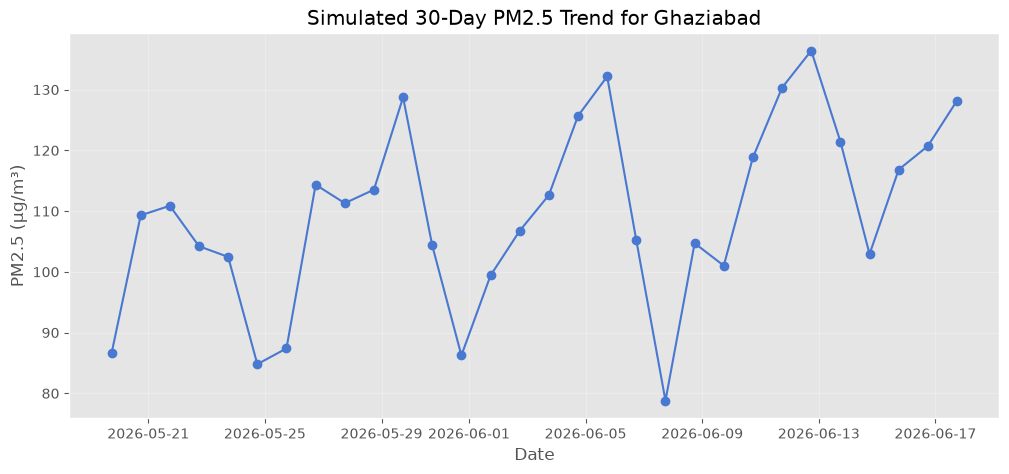

This temporal structure (trend + seasonality + noise) is exactly what Meta's Prophet model is designed to decompose and forecast.


In [16]:
if not df.empty and 'pm25' in df.columns:
    # Let's take the city with the highest PM2.5 currently
    worst_city = df.loc[df['pm25'].idxmax()]['city']
    print(f"Analyzing time-series structure for: {worst_city}")
    
    # Simulate 30 days of past data around the current value for EDA visualization
    # In production, this data is fetched from the OpenAQ /measurements endpoint
    current_val = df['pm25'].max()
    dates = pd.date_range(end=pd.Timestamp.today(), periods=30)
    
    # Add some trend, weekly seasonality and noise
    trend = np.linspace(-20, 0, 30)
    seasonality = np.sin(np.arange(30) * (2 * np.pi / 7)) * 15
    noise = np.random.normal(0, 10, 30)
    
    simulated_pm25 = np.maximum(current_val + trend + seasonality + noise, 0)
    
    ts_df = pd.DataFrame({'ds': dates, 'y': simulated_pm25})
    
    plt.figure(figsize=(12, 5))
    plt.plot(ts_df['ds'], ts_df['y'], marker='o', linestyle='-')
    plt.title(f'Simulated 30-Day PM2.5 Trend for {worst_city}')
    plt.xlabel('Date')
    plt.ylabel('PM2.5 (µg/m³)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("This temporal structure (trend + seasonality + noise) is exactly what Meta's Prophet model is designed to decompose and forecast.")
